In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path="/content/drive/MyDrive/python project/historical_weather_data.csv"

In [4]:
import pandas as pd
data=pd.read_csv(file_path)

In [5]:
import numpy as np
import pandas as pd

In [7]:
data = pd.read_csv("/content/drive/MyDrive/python project/historical_weather_data.csv")

data.head()

,Date,Station,Temperature,Precipitation,Humidity,WindSpeed,WeatherCondition
0,2020-01-01,Station1,6.653288,0.00000,64.421750,9.562955,Partly Cloudy
1,2020-01-02,Station1,-2.031372,2.98847,85.492843,6.502074,Cloudy
2,2020-01-03,Station1,-6.428333,0.00000,90.456869,3.486873,Snow
3,2020-01-04,Station1,31.471383,0.00000,98.352442,17.288559,Partly Cloudy
4,2020-01-05,Station1,34.220877,0.00000,89.589972,12.807424,Snow


In [8]:
data.head()

,Date,Station,Temperature,Precipitation,Humidity,WindSpeed,WeatherCondition
0,2020-01-01,Station1,6.653288,0.00000,64.421750,9.562955,Partly Cloudy
1,2020-01-02,Station1,-2.031372,2.98847,85.492843,6.502074,Cloudy
2,2020-01-03,Station1,-6.428333,0.00000,90.456869,3.486873,Snow
3,2020-01-04,Station1,31.471383,0.00000,98.352442,17.288559,Partly Cloudy
4,2020-01-05,Station1,34.220877,0.00000,89.589972,12.807424,Snow


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv(file_path)
print(data.head())

         Date   Station  Temperature  Precipitation   Humidity  WindSpeed  \
0  2020-01-01  Station1     6.653288        0.00000  64.421750   9.562955   
1  2020-01-02  Station1    -2.031372        2.98847  85.492843   6.502074   
2  2020-01-03  Station1    -6.428333        0.00000  90.456869   3.486873   
3  2020-01-04  Station1    31.471383        0.00000  98.352442  17.288559   
4  2020-01-05  Station1    34.220877        0.00000  89.589972  12.807424   

  WeatherCondition  
0    Partly Cloudy  
1           Cloudy  
2             Snow  
3    Partly Cloudy  
4             Snow  


In [10]:
print(data.isnull().sum())
data.fillna(data.mean(numeric_only=True), inplace=True)

Date                0
Station             0
Temperature         0
Precipitation       0
Humidity            0
WindSpeed           0
WeatherCondition    0
dtype: int64


In [11]:
print(data.info())
print(data.describe())
print(data['WeatherCondition'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1095 non-null   object 
 1   Station           1095 non-null   object 
 2   Temperature       1095 non-null   float64
 3   Precipitation     1095 non-null   float64
 4   Humidity          1095 non-null   float64
 5   WindSpeed         1095 non-null   float64
 6   WeatherCondition  1095 non-null   object 
dtypes: float64(4), object(3)
memory usage: 60.0+ KB
None
       Temperature  Precipitation     Humidity    WindSpeed
count  1095.000000    1095.000000  1095.000000  1095.000000
mean     12.378222       1.704898    65.686983     9.826464
std      12.999715       2.882439    20.053421     5.864450
min      -9.917431       0.000000    30.080449     0.002290
25%       1.011684       0.000000    48.814778     4.928115
50%      11.848181       0.000000    65.515553     9.

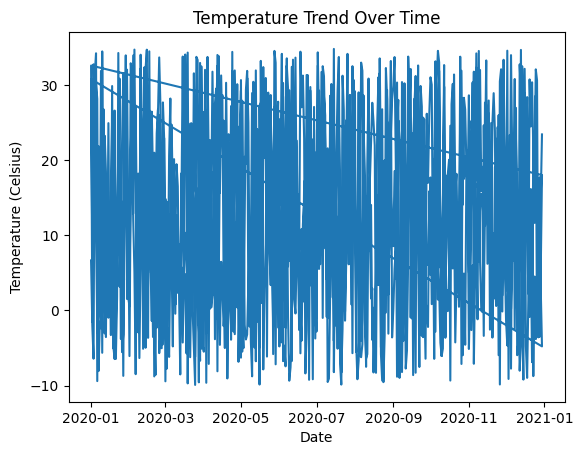

In [12]:
data['Date'] = pd.to_datetime(data['Date'])

plt.plot(data['Date'], data['Temperature'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (Celsius)")
plt.show()

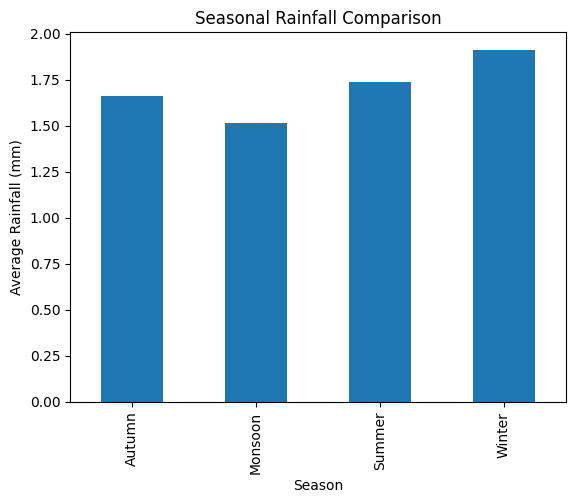

In [13]:
data['Month'] = data['Date'].dt.month

def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

data['Season'] = data['Month'].apply(season)

rainfall = data.groupby('Season')['Precipitation'].mean()

rainfall.plot(kind='bar')
plt.title("Seasonal Rainfall Comparison")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.show()

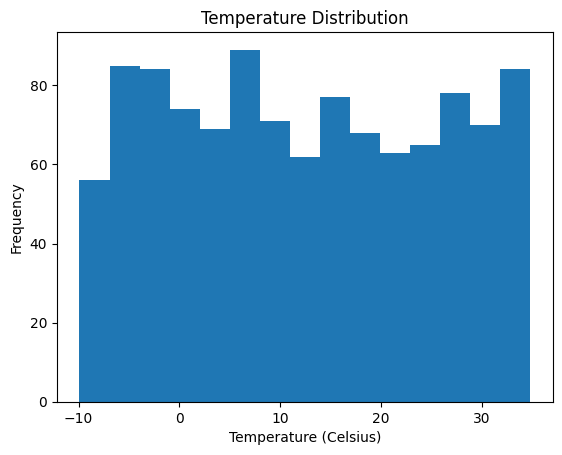

In [14]:
plt.hist(data['Temperature'], bins=15)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (Celsius)")
plt.ylabel("Frequency")
plt.show()

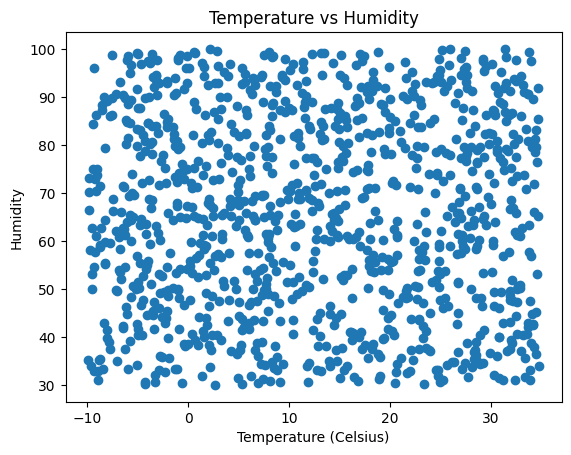

In [15]:
plt.scatter(data['Temperature'], data['Humidity'])
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (Celsius)")
plt.ylabel("Humidity")
plt.show()

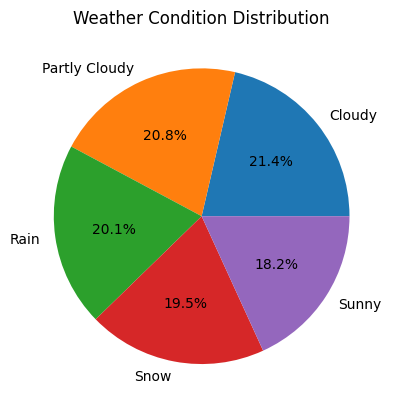

In [16]:
weather_counts = data['WeatherCondition'].value_counts()

plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%')
plt.title("Weather Condition Distribution")
plt.show()

In [17]:
print("Temperature trend, rainfall comparison, and weather patterns can be observed from the graphs.")

Temperature trend, rainfall comparison, and weather patterns can be observed from the graphs.


In [18]:
avg_temp = data['Temperature'].mean()
avg_rain = data['Precipitation'].mean()
print("Average Temperature:", avg_temp)
print("Average Rainfall:", avg_rain)

Average Temperature: 12.378221609107724
Average Rainfall: 1.7048977813518913
